**Objetivo del modelo:**
Predecir la calificación promedio de un libro a partir de su número de páginas, género e idioma.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

libros = pd.read_csv("/content/books_1.Best_Books_Ever.csv")


In [9]:
datos = libros[["rating", "pages", "genres", "language"]].copy()

datos.head()

,rating,pages,genres,language
0,4.33,374,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",English
1,4.50,870,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",English
2,4.28,324,"['Classics', 'Fiction', 'Historical Fiction', ...",English
3,4.26,279,"['Classics', 'Fiction', 'Romance', 'Historical...",English
4,3.60,501,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",English


In [10]:
datos.isnull().sum()

,0
rating,0
pages,2347
genres,0
language,3806


In [19]:
datos["pages"] = pd.to_numeric(
    datos["pages"],
    errors="coerce"
)

datos["genre_principal"] = datos["genres"].str.extract(
    r"\['([^']+)'"
)

datos[["rating", "pages", "genre_principal", "language"]].head()

,rating,pages,genre_principal,language
0,4.33,374.0,Young Adult,English
1,4.50,870.0,Fantasy,English
2,4.28,324.0,Classics,English
3,4.26,279.0,Classics,English
4,3.60,501.0,Young Adult,English


In [22]:
datos_limpios = datos[
    ["rating", "pages", "genre_principal", "language"]
].dropna().copy()

datos_limpios = datos_limpios[
    (datos_limpios["rating"] > 0) &
    (datos_limpios["pages"] > 0)
]

datos_limpios = datos_limpios.reset_index(drop=True)

In [23]:
print("Cantidad de libros después de la limpieza:")
print(len(datos_limpios))

print("\nDatos faltantes:")
print(datos_limpios.isnull().sum())

Cantidad de libros después de la limpieza:
43833

Datos faltantes:
rating             0
pages              0
genre_principal    0
language           0
dtype: int64


In [24]:
datos_limpios[["rating", "pages"]].describe()

,rating,pages
count,43833.000000,43833.000000
mean,3.995314,338.053179
std,0.289206,251.531711
min,1.900000,1.000000
25%,3.810000,224.000000
50%,4.010000,312.000000
75%,4.190000,400.000000
max,5.000000,14777.000000


El dataset contiene 43.833 libros. La calificación promedio es de aproximadamente 4 estrellas y presenta poca variabilidad. La cantidad promedio de páginas es 338, mientras que la mediana es 312. La diferencia entre ambas medidas y el máximo de 14.777 páginas indican la presencia de libros con una extensión muy superior a la habitual(Revisando el dataset, vi que se trata de un dato que expresa la cantidad de paginas de una colección de libros completa de The Story of Civilization). Deberia considerar este valor extremo antes de entrenar el modelo porque podrían influir en los resultados.

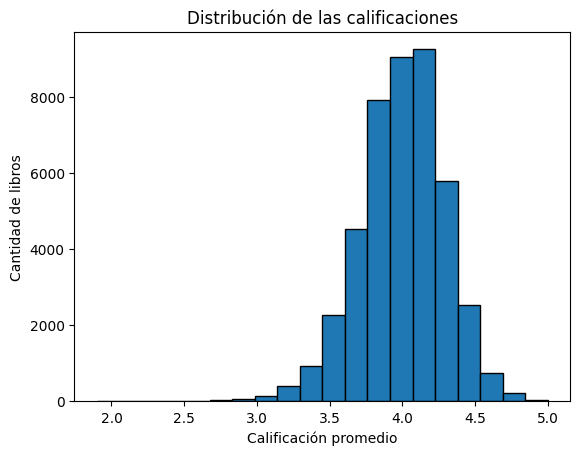

In [25]:
plt.hist(
    datos_limpios["rating"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Calificación promedio")
plt.ylabel("Cantidad de libros")
plt.title("Distribución de las calificaciones")

plt.show()

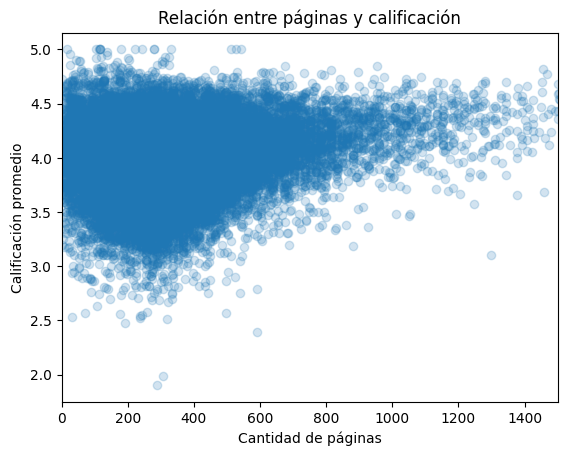

In [26]:
plt.scatter(
    datos_limpios["pages"],
    datos_limpios["rating"],
    alpha=0.2
)

plt.xlabel("Cantidad de páginas")
plt.ylabel("Calificación promedio")
plt.title("Relación entre páginas y calificación")

plt.xlim(0, 1500)

plt.show()

Los libros más extensos parecen concentrarse en calificaciones cercanas o superiores a 4 estrellas, aunque existe una gran dispersión entre los libros de menor extensión. Por lo tanto, la cantidad de páginas no sería suficiente por sí sola para predecir la calificación.

Seleccionaré los 10 generos más frecuentes para trabajar visualmente.

In [27]:
top_generos = datos_limpios[
    "genre_principal"
].value_counts().head(10).index

promedio_generos = datos_limpios[
    datos_limpios["genre_principal"].isin(top_generos)
].groupby("genre_principal")["rating"].mean().sort_values()

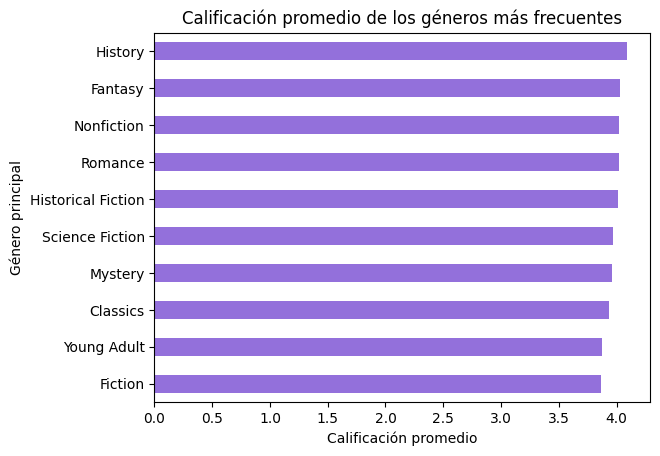

In [28]:
promedio_generos.plot(
    kind="barh",
    color="mediumpurple"
)

plt.xlabel("Calificación promedio")
plt.ylabel("Género principal")
plt.title("Calificación promedio de los géneros más frecuentes")

plt.show()

Entre los diez géneros más frecuentes, Historia es el que presenta la calificación promedio más alta, mientras que Ficción y Literatura Juvenil presentan los promedios más bajos. Pero las diferencias son muy reducidas, ya que todos los géneros se encuentran en una calificacipon de estrellas mayor a 3.5 y menor a 4.1. El género podría aportar información al modelo, pero no sera suficiente por sí solo para predecir la calificación.

Vamos a explorar los 10 idiomas más frecuentes:

In [29]:
top_idiomas = datos_limpios[
    "language"
].value_counts().head(10).index

promedio_idiomas = datos_limpios[
    datos_limpios["language"].isin(top_idiomas)
].groupby("language")["rating"].mean().sort_values()

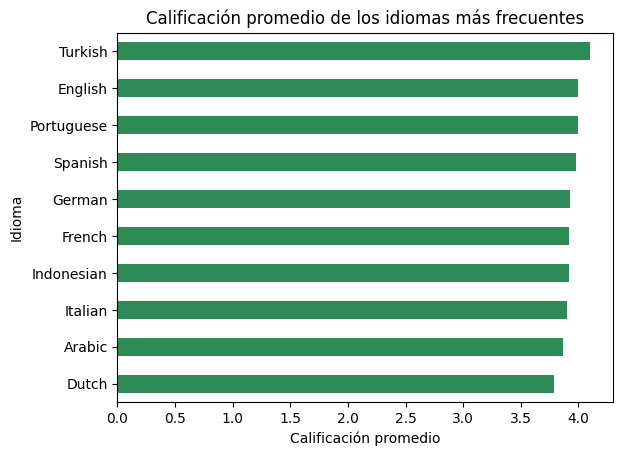

In [30]:
promedio_idiomas.plot(
    kind="barh",
    color="seagreen"
)

plt.xlabel("Calificación promedio")
plt.ylabel("Idioma")
plt.title("Calificación promedio de los idiomas más frecuentes")

plt.show()

las diferencias entre los idiomas, al igual que la de calificación, son pequeñas, ya que todos los promedios se encuentran aproximadamente entre 3,8 y 4,1. Por lo que el idioma podría aportar cierta información para predecir la calificación, aunque tampoco parece ser una variable determinante por sí sola.

Inicio el modelo predictor


In [33]:
X = datos_limpios[
    ["pages", "genre_principal", "language"]
].copy()

X = pd.get_dummies(
    X,
    columns=["genre_principal", "language"],
    drop_first=True
)

y = datos_limpios["rating"]

print("Dimensiones de X:", X.shape)
X.head()

Dimensiones de X: (43833, 454)


,pages,genre_principal_21st Century,genre_principal_2nd Grade,genre_principal_Abuse,genre_principal_Academic,genre_principal_Action,genre_principal_Adoption,genre_principal_Adult,genre_principal_Adventure,genre_principal_Africa,...,language_Spanish,language_Swedish,language_Tagalog,language_Tamil,language_Telugu,language_Turkish,language_Ukrainian,language_Undetermined,language_Urdu,language_Vietnamese
0,374.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,870.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,324.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,279.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,501.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
from sklearn.model_selection import train_test_split

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [36]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_entrenamiento, y_entrenamiento)

LinearRegression()

In [39]:
predicciones = modelo.predict(X_prueba)

predicciones[:5]

array([3.84410922, 4.08755711, 3.81979193, 3.98368659, 4.17194091])

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_prueba, predicciones)
mse = mean_squared_error(y_prueba, predicciones)
r2 = r2_score(y_prueba, predicciones)

print("Error absoluto medio (MAE):", mae)
print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R²):", r2)

Error absoluto medio (MAE): 0.20456342102664662
Error cuadrático medio (MSE): 0.07005258459380133
Coeficiente de determinación (R²): 0.168893528345057


El modelo de regresión lineal obtuvo un error absoluto medio de aproximadamente 0,20 puntos, lo que significa que en promero,sus predicciones se alejan eso de la calificación real. El coeficiente de determinación fue de 0,169, por lo que las variables número de páginas, género principal e idioma explican aproximadamente el 16,9 % de la variación de las calificaciones. Estas variables aportan cierta información, pero no resultan suficientes para predecir con precisión la valoración de un libro. Podrían incorporarse otras características, como la cantidad de reseñas, el autor o el año de publicación, para intentar mejorar el modelo.

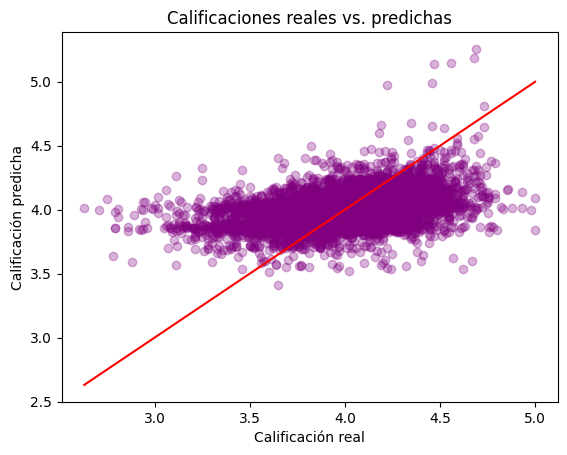

In [41]:
plt.scatter(
    y_prueba,
    predicciones,
    alpha=0.3,
    color="purple"
)

plt.plot(
    [y_prueba.min(), y_prueba.max()],
    [y_prueba.min(), y_prueba.max()],
    color="red"
)

plt.xlabel("Calificación real")
plt.ylabel("Calificación predicha")
plt.title("Calificaciones reales vs. predichas")

plt.show()

En el gráfico se observa que las predicciones se concentran principalmente alrededor de una calificación de 4. Los puntos no siguen completamente la línea roja, que representa las predicciones ideales y esto indica que el modelo puede aproximarse a las calificaciones promedio, pero que le cuesta predecir valores extremos.